# Projeto de predição de preços de Airbnb no Rio de Janeiro

Nosso objetivo com este projeto é gerar modelos capazes de estimar o preço de um Airbnb no Rio de Janeiro dadas as características de um determinado imóvel, como localização, sazonalidade ,tamanho do imóvel entre outras variáveis que veremos a seguir.

### Importação das bibliotecas

In [3]:
import pandas as pd
import pathlib 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [4]:
caminho_base = pathlib.Path(r"dataset/dataset")
dic_meses = {
    "jan" : 1,
    "fev" : 2,
    "mar" : 3,
    "abr" : 4,
    "mai" : 5,
    "jun" : 6,
    "jul" : 7,
    "ago" : 8,
    "set" : 9,
    "out" : 10,
    "nov" : 11,
    "dez" : 12
}

Bases_df = pd.DataFrame()
for arquivo in caminho_base.iterdir():
    nome_mes = arquivo.name[:3]
    mes = dic_meses[nome_mes]
    ano = arquivo.name[-8:-4]
    df = pd.read_csv(caminho_base / arquivo.name)   
    Bases_df = pd.concat([Bases_df , df])
    Bases_df["mes"] = mes
    Bases_df["ano"] = ano
    

C:\Users\Isabella\AppData\Local\Temp\ipykernel_10468\951911489.py:22: DtypeWarning: Columns (0: monthly_price, 1: license) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(caminho_base / arquivo.name)
C:\Users\Isabella\AppData\Local\Temp\ipykernel_10468\951911489.py:22: DtypeWarning: Columns (0: weekly_price, 1: monthly_price, 2: license) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(caminho_base / arquivo.name)
C:\Users\Isabella\AppData\Local\Temp\ipykernel_10468\951911489.py:22: DtypeWarning: Columns (0: license) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(caminho_base / arquivo.name)


In [5]:
display(Bases_df.head())

,id,listing_url,scrape_id,last_scraped,name,summary,space,description,experiences_offered,neighborhood_overview,...,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm,maximum_nights_avg_ntm,number_of_reviews_ltm,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms
0,14063,https://www.airbnb.com/rooms/14063,20180414160018,2018-04-14,Living in a Postcard,"Besides the most iconic's view, our apartment ...",NaN,"Besides the most iconic's view, our apartment ...",none,Best and favorite neighborhood of Rio. Perfect...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,17878,https://www.airbnb.com/rooms/17878,20180414160018,2018-04-14,Very Nice 2Br - Copacabana - WiFi,Please note that special rates apply for New Y...,- large balcony which looks out on pedestrian ...,Please note that special rates apply for New Y...,none,This is the best spot in Rio. Everything happe...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,24480,https://www.airbnb.com/rooms/24480,20180414160018,2018-04-14,Nice and cozy near Ipanema Beach,My studio is located in the best of Ipanema. ...,The studio is located at Vinicius de Moraes St...,My studio is located in the best of Ipanema. ...,none,"The beach, the lagoon, Ipanema is a great loca...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,25026,https://www.airbnb.com/rooms/25026,20180414160018,2018-04-14,Beautiful Modern Decorated Studio in Copa,"Our apartment is a little gem, everyone loves ...",This newly renovated studio (last renovations ...,"Our apartment is a little gem, everyone loves ...",none,Copacabana is a lively neighborhood and the ap...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,31560,https://www.airbnb.com/rooms/31560,20180414160018,2018-04-14,NICE & COZY 1BDR - IPANEMA BEACH,This nice and clean 1 bedroom apartment is loc...,This nice and clean 1 bedroom apartment is loc...,This nice and clean 1 bedroom apartment is loc...,none,Die Nachbarschaft von Ipanema ist super lebend...,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Criando arquivo excel para visualizar as colunas do dataframe



Como temos muitas colunas no dataset, podemos gerar um overfit e nosso modelo pode não ser muito eficiente. Por isso, vamos analisar que informações podemos tirar e que informações fazem sentido manter.

In [6]:
print(list(Bases_df.columns))
Bases_df.head(1000).to_csv("Base_Parcial.csv" , sep = ';')

['id', 'listing_url', 'scrape_id', 'last_scraped', 'name', 'summary', 'space', 'description', 'experiences_offered', 'neighborhood_overview', 'notes', 'transit', 'access', 'interaction', 'house_rules', 'thumbnail_url', 'medium_url', 'picture_url', 'xl_picture_url', 'host_id', 'host_url', 'host_name', 'host_since', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood', 'host_listings_count', 'host_total_listings_count', 'host_verifications', 'host_has_profile_pic', 'host_identity_verified', 'street', 'neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'city', 'state', 'zipcode', 'market', 'smart_location', 'country_code', 'country', 'latitude', 'longitude', 'is_location_exact', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bedrooms', 'beds', 'bed_type', 'amenities', 'square_feet', 'price', 'weekly_price', 'monthly_price', '

### Colunas a serem retiradas
- Colunas a serem excluídas
    1. Colunas com informações numéricas irrelevantes sobre o Airbnb 
    2. Colunas com informações extremamente parecidas
    3. Colunas preenchidas com texto livre
    4. Colunas em que os valores são todos iguais

In [7]:
# colunas restantes pos analise no excel
analise_df = pd.read_csv("Base_corrigida.csv" , sep = ";" )
colunas = analise_df.columns.delete(0)
analise_df = Bases_df[colunas].reset_index(drop = True)

print(len(colunas))
display(analise_df)


32


,host_response_time,host_response_rate,host_is_superhost,host_listings_count,host_identity_verified,neighbourhood_cleansed,property_type,room_type,accommodates,bathrooms,...,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,is_business_travel_ready,cancellation_policy,mes,ano
0,NaN,NaN,f,1.0,t,Botafogo,Apartment,Entire home/apt,4,1.0,...,9.0,9.0,9.0,9.0,9.0,f,f,strict_14_with_grace_period,9,2019
1,within an hour,100%,t,2.0,f,Copacabana,Condominium,Entire home/apt,5,1.0,...,9.0,10.0,10.0,9.0,9.0,t,f,strict,9,2019
2,within an hour,100%,f,1.0,t,Ipanema,Apartment,Entire home/apt,2,1.0,...,10.0,10.0,10.0,10.0,9.0,f,f,strict,9,2019
3,within an hour,100%,f,3.0,t,Copacabana,Apartment,Entire home/apt,3,1.0,...,10.0,10.0,10.0,10.0,9.0,f,f,strict,9,2019
4,within an hour,100%,t,1.0,t,Ipanema,Apartment,Entire home/apt,3,1.0,...,10.0,10.0,10.0,10.0,9.0,t,f,strict,9,2019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
902205,within an hour,93%,f,0.0,f,Barra da Tijuca,Apartment,Entire home/apt,4,1.0,...,NaN,NaN,NaN,NaN,NaN,f,f,flexible,9,2019
902206,NaN,NaN,f,0.0,f,Jacarepaguá,Apartment,Entire home/apt,4,2.0,...,NaN,NaN,NaN,NaN,NaN,f,f,flexible,9,2019
902207,within a few hours,74%,f,32.0,t,Copacabana,Apartment,Entire home/apt,5,1.0,...,NaN,NaN,NaN,NaN,NaN,f,f,strict_14_with_grace_period,9,2019
902208,NaN,NaN,f,0.0,t,Barra da Tijuca,Apartment,Entire home/apt,4,1.0,...,NaN,NaN,NaN,NaN,NaN,f,f,strict_14_with_grace_period,9,2019


### A tabela acima é a tabela que será utilizada como base para nossas análises

In [8]:
display(analise_df.iloc[: , :20].info())
display(analise_df.iloc[: , 20:].info())


<class 'pandas.DataFrame'>
RangeIndex: 902210 entries, 0 to 902209
Data columns (total 20 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   host_response_time      500367 non-null  str    
 1   host_response_rate      500364 non-null  str    
 2   host_is_superhost       901750 non-null  str    
 3   host_listings_count     901750 non-null  float64
 4   host_identity_verified  901750 non-null  str    
 5   neighbourhood_cleansed  902210 non-null  str    
 6   property_type           902210 non-null  str    
 7   room_type               902210 non-null  str    
 8   accommodates            902210 non-null  int64  
 9   bathrooms               900486 non-null  float64
 10  bedrooms                901360 non-null  float64
 11  beds                    899708 non-null  float64
 12  amenities               902210 non-null  str    
 13  price                   902210 non-null  str    
 14  security_deposit        480930 

None

<class 'pandas.DataFrame'>
RangeIndex: 902210 entries, 0 to 902209
Data columns (total 12 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   review_scores_rating         454194 non-null  float64
 1   review_scores_accuracy       453624 non-null  float64
 2   review_scores_cleanliness    453797 non-null  float64
 3   review_scores_checkin        453560 non-null  float64
 4   review_scores_communication  453795 non-null  float64
 5   review_scores_location       453657 non-null  float64
 6   review_scores_value          453659 non-null  float64
 7   instant_bookable             902210 non-null  str    
 8   is_business_travel_ready     902210 non-null  str    
 9   cancellation_policy          902210 non-null  str    
 10  mes                          902210 non-null  int64  
 11  ano                          902210 non-null  str    
dtypes: float64(7), int64(1), str(4)
memory usage: 82.6 MB


None

 Diante dos dados acima, podemos verificar que existem diversos valores faltantes em algumas das colunas, vamos tratar os valores faltantes da base da seguinte maneira: Vamos fazer analises considerando duas bases distintas. Uma delas desconsiderando colunas com mais de quarenta por cento das linhas faltantes, e na outra, vamos tentar preencher essas colunas da maneira mais conveniente possível. A ideia é fazer uma seleção de modelos para entender se essas covariáveis são relevantes ou não em nossas previsões. 

In [9]:
# Dados sem as colunas:
print(f"A metade do número de linhas é {analise_df.index[-1] * 0.5}")
colunas_excluidas = []

for coluna in analise_df.columns:
    print(analise_df[coluna].isnull().sum())
    if analise_df[coluna].isnull().sum() > analise_df.index[-1] * 0.4:
        colunas_excluidas.append(coluna)

print(colunas_excluidas)

A metade do número de linhas é 451104.5
401843
401846
460
460
460
0
0
0
0
1724
850
2502
0
0
421280
313506
0
0
0
0
448016
448586
448413
448650
448415
448553
448551
0
0
0
0
0
['host_response_time', 'host_response_rate', 'security_deposit', 'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness', 'review_scores_checkin', 'review_scores_communication', 'review_scores_location', 'review_scores_value']


É importante notar que em nenhuma das linhas a maioria dos valores são faltantes. Retiramos entã as linhas com mais de 40 porcento de valores faltantes. Vamos primeiro fazer npssas analises prrenchendo as linhas dessas colunas com valores faltantes e depois separar os dados para fazer nossa seleção de modelos.

In [10]:
#print(analise_df["host_response_rate"].value_counts())
rate = analise_df[["host_response_rate"]].dropna()
rate = rate.reset_index(drop = True)
rate = rate["host_response_rate"].tolist()
aux = []
    
for numero in rate:
    aux.append(float(numero[:-1])/100)

rate = pd.Series(aux)

display(rate.describe())

analise_df["host_response_rate"] = analise_df["host_response_rate"].fillna("100%")

analise_df["host_response_rate"] = analise_df["host_response_rate"].str.replace("%", "").astype(np.float64)

aux = []

for linha in analise_df.index:
    aux.append(analise_df.loc[linha , "host_response_rate"])

aux = pd.Series(aux)
analise_df["aux"] = aux 
analise_df["host_response_rate"] = analise_df["aux"]
analise_df = analise_df.drop(columns = "aux")
display(analise_df)


count    500364.000000
mean          0.851702
std           0.276939
min           0.000000
25%           0.830000
50%           1.000000
75%           1.000000
max           1.000000
dtype: float64

,host_response_time,host_response_rate,host_is_superhost,host_listings_count,host_identity_verified,neighbourhood_cleansed,property_type,room_type,accommodates,bathrooms,...,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,is_business_travel_ready,cancellation_policy,mes,ano
0,NaN,100.0,f,1.0,t,Botafogo,Apartment,Entire home/apt,4,1.0,...,9.0,9.0,9.0,9.0,9.0,f,f,strict_14_with_grace_period,9,2019
1,within an hour,100.0,t,2.0,f,Copacabana,Condominium,Entire home/apt,5,1.0,...,9.0,10.0,10.0,9.0,9.0,t,f,strict,9,2019
2,within an hour,100.0,f,1.0,t,Ipanema,Apartment,Entire home/apt,2,1.0,...,10.0,10.0,10.0,10.0,9.0,f,f,strict,9,2019
3,within an hour,100.0,f,3.0,t,Copacabana,Apartment,Entire home/apt,3,1.0,...,10.0,10.0,10.0,10.0,9.0,f,f,strict,9,2019
4,within an hour,100.0,t,1.0,t,Ipanema,Apartment,Entire home/apt,3,1.0,...,10.0,10.0,10.0,10.0,9.0,t,f,strict,9,2019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
902205,within an hour,93.0,f,0.0,f,Barra da Tijuca,Apartment,Entire home/apt,4,1.0,...,NaN,NaN,NaN,NaN,NaN,f,f,flexible,9,2019
902206,NaN,100.0,f,0.0,f,Jacarepaguá,Apartment,Entire home/apt,4,2.0,...,NaN,NaN,NaN,NaN,NaN,f,f,flexible,9,2019
902207,within a few hours,74.0,f,32.0,t,Copacabana,Apartment,Entire home/apt,5,1.0,...,NaN,NaN,NaN,NaN,NaN,f,f,strict_14_with_grace_period,9,2019
902208,NaN,100.0,f,0.0,t,Barra da Tijuca,Apartment,Entire home/apt,4,1.0,...,NaN,NaN,NaN,NaN,NaN,f,f,strict_14_with_grace_period,9,2019


In [11]:
display(analise_df["host_response_time"].value_counts())

# podemos ver que os tempos de resposta não variam muito, logo vamos tirar essa coluna

analise_df = analise_df.drop(columns = "host_response_time")
display(analise_df)
# Cleaning_fee tem mais de 300000 valores nulos

host_response_time
within an hour        209720
within a few hours    130453
within a day          111417
a few days or more     48777
Name: count, dtype: int64

,host_response_rate,host_is_superhost,host_listings_count,host_identity_verified,neighbourhood_cleansed,property_type,room_type,accommodates,bathrooms,bedrooms,...,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,is_business_travel_ready,cancellation_policy,mes,ano
0,100.0,f,1.0,t,Botafogo,Apartment,Entire home/apt,4,1.0,0.0,...,9.0,9.0,9.0,9.0,9.0,f,f,strict_14_with_grace_period,9,2019
1,100.0,t,2.0,f,Copacabana,Condominium,Entire home/apt,5,1.0,2.0,...,9.0,10.0,10.0,9.0,9.0,t,f,strict,9,2019
2,100.0,f,1.0,t,Ipanema,Apartment,Entire home/apt,2,1.0,1.0,...,10.0,10.0,10.0,10.0,9.0,f,f,strict,9,2019
3,100.0,f,3.0,t,Copacabana,Apartment,Entire home/apt,3,1.0,1.0,...,10.0,10.0,10.0,10.0,9.0,f,f,strict,9,2019
4,100.0,t,1.0,t,Ipanema,Apartment,Entire home/apt,3,1.0,1.0,...,10.0,10.0,10.0,10.0,9.0,t,f,strict,9,2019
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
902205,93.0,f,0.0,f,Barra da Tijuca,Apartment,Entire home/apt,4,1.0,0.0,...,NaN,NaN,NaN,NaN,NaN,f,f,flexible,9,2019
902206,100.0,f,0.0,f,Jacarepaguá,Apartment,Entire home/apt,4,2.0,2.0,...,NaN,NaN,NaN,NaN,NaN,f,f,flexible,9,2019
902207,74.0,f,32.0,t,Copacabana,Apartment,Entire home/apt,5,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,f,f,strict_14_with_grace_period,9,2019
902208,100.0,f,0.0,t,Barra da Tijuca,Apartment,Entire home/apt,4,1.0,1.0,...,NaN,NaN,NaN,NaN,NaN,f,f,strict_14_with_grace_period,9,2019


In [12]:
# Tratando a coluna security_deposit (Vamos considerar que as linhas nulas não possuem deposito de segurança)
analise_df["security_deposit"] = analise_df["security_deposit"].fillna("0")

analise_df["security_deposit"] = analise_df["security_deposit"].str.replace("$" , "").str.replace("," , "").astype(np.float64)


In [13]:
# Tratando a coluna cleaning_fee (Vamos considerar que as linhas nulas não possuem taxa de limpeza)

analise_df["cleaning_fee"] = analise_df["cleaning_fee"].fillna("0")

analise_df["cleaning_fee"] = analise_df["cleaning_fee"].str.replace("$" , "").str.replace(",", "").astype(np.float64)

In [14]:
# Tratamento da coluna review_scores_rating (Vamos substiruir os valores faltantes pela mediana que é 98, usando a tabela que descreve as estatísticas da coluna)
rate = analise_df[["review_scores_rating"]].dropna()
rate = rate.reset_index(drop = True)

display(rate.describe())

analise_df["review_scores_rating"] = analise_df["review_scores_rating"].fillna(98.0)



,review_scores_rating
count,454194.000000
mean,94.442639
std,9.543860
min,20.000000
25%,93.000000
50%,98.000000
75%,100.000000
max,100.000000


In [15]:
# Tratatamento da coluna review_scores_accuracy (Preencheremos usando a média entre média e mediana)
rate = analise_df[["review_scores_accuracy"]].dropna()
rate = rate.reset_index(drop = True)

display(rate.describe())


analise_df["review_scores_accuracy"] = analise_df["review_scores_accuracy"].fillna(9.8)


,review_scores_accuracy
count,453624.000000
mean,9.617375
std,0.929905
min,2.000000
25%,10.000000
50%,10.000000
75%,10.000000
max,10.000000


In [16]:
# Tratatamento da coluna review_cleanliness (Preencheremos usando a média entre média e mediana 9.7)
rate = analise_df[["review_scores_cleanliness"]].dropna()
rate = rate.reset_index(drop = True)

display(rate.describe())


analise_df["review_scores_cleanliness"] = analise_df["review_scores_cleanliness"].fillna(9.7)


,review_scores_cleanliness
count,453797.000000
mean,9.402281
std,1.124812
min,2.000000
25%,9.000000
50%,10.000000
75%,10.000000
max,10.000000


In [17]:
# Tratatamento da coluna review_scores_checkin (Preencheremos usando a média entre média e mediana 9.9)
rate = analise_df[["review_scores_checkin"]].dropna()
rate = rate.reset_index(drop = True)

display(rate.describe())


analise_df["review_scores_checkin"] = analise_df["review_scores_checkin"].fillna(9.9)


,review_scores_checkin
count,453560.000000
mean,9.781674
std,0.760126
min,2.000000
25%,10.000000
50%,10.000000
75%,10.000000
max,10.000000


In [18]:
# Tratatamento da coluna review_scores_communication (Preencheremos usando a média entre média e mediana)
rate = analise_df[["review_scores_communication"]].dropna()
rate = rate.reset_index(drop = True)

display(rate.describe())


analise_df["review_scores_communication"] = analise_df["review_scores_communication"].fillna(9.9)


,review_scores_communication
count,453795.000000
mean,9.750691
std,0.798317
min,2.000000
25%,10.000000
50%,10.000000
75%,10.000000
max,10.000000


In [19]:
# Tratatamento da coluna review_scores_location (Preencheremos usando a média entre média e mediana)
rate = analise_df[["review_scores_location"]].dropna()
rate = rate.reset_index(drop = True)

display(rate.describe())


analise_df["review_scores_location"] = analise_df["review_scores_location"].fillna(9.85)

,review_scores_location
count,453657.000000
mean,9.715166
std,0.767624
min,2.000000
25%,10.000000
50%,10.000000
75%,10.000000
max,10.000000


In [20]:
# Tratatamento da coluna review_scores_value (Preencheremos usando a média entre média e mediana)
rate = analise_df[["review_scores_value"]].dropna()
rate = rate.reset_index(drop = True)

display(rate.describe())


analise_df["review_scores_value"] = analise_df["review_scores_value"].fillna(9.75)

,review_scores_value
count,453659.000000
mean,9.309587
std,1.039211
min,2.000000
25%,9.000000
50%,10.000000
75%,10.000000
max,10.000000


In [21]:
display(analise_df.iloc[: , :20].info())
display(analise_df.iloc[: , 20:].info())


<class 'pandas.DataFrame'>
RangeIndex: 902210 entries, 0 to 902209
Data columns (total 20 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   host_response_rate      902210 non-null  float64
 1   host_is_superhost       901750 non-null  str    
 2   host_listings_count     901750 non-null  float64
 3   host_identity_verified  901750 non-null  str    
 4   neighbourhood_cleansed  902210 non-null  str    
 5   property_type           902210 non-null  str    
 6   room_type               902210 non-null  str    
 7   accommodates            902210 non-null  int64  
 8   bathrooms               900486 non-null  float64
 9   bedrooms                901360 non-null  float64
 10  beds                    899708 non-null  float64
 11  amenities               902210 non-null  str    
 12  price                   902210 non-null  str    
 13  security_deposit        902210 non-null  float64
 14  cleaning_fee            902210 

None

<class 'pandas.DataFrame'>
RangeIndex: 902210 entries, 0 to 902209
Data columns (total 11 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   review_scores_accuracy       902210 non-null  float64
 1   review_scores_cleanliness    902210 non-null  float64
 2   review_scores_checkin        902210 non-null  float64
 3   review_scores_communication  902210 non-null  float64
 4   review_scores_location       902210 non-null  float64
 5   review_scores_value          902210 non-null  float64
 6   instant_bookable             902210 non-null  str    
 7   is_business_travel_ready     902210 non-null  str    
 8   cancellation_policy          902210 non-null  str    
 9   mes                          902210 non-null  int64  
 10  ano                          902210 non-null  str    
dtypes: float64(6), int64(1), str(4)
memory usage: 75.7 MB


None

Para as demais colunas, vamos desconsiderar as linhas com valores faltantes, pois representam poucos valores em comparação com o total de linhas

In [22]:
analise_df = analise_df.dropna()
display(analise_df.iloc[: , :20].info())
display(analise_df.iloc[: , 20:].info())


<class 'pandas.DataFrame'>
Index: 897709 entries, 0 to 902209
Data columns (total 20 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   host_response_rate      897709 non-null  float64
 1   host_is_superhost       897709 non-null  str    
 2   host_listings_count     897709 non-null  float64
 3   host_identity_verified  897709 non-null  str    
 4   neighbourhood_cleansed  897709 non-null  str    
 5   property_type           897709 non-null  str    
 6   room_type               897709 non-null  str    
 7   accommodates            897709 non-null  int64  
 8   bathrooms               897709 non-null  float64
 9   bedrooms                897709 non-null  float64
 10  beds                    897709 non-null  float64
 11  amenities               897709 non-null  str    
 12  price                   897709 non-null  str    
 13  security_deposit        897709 non-null  float64
 14  cleaning_fee            897709 non-n

None

<class 'pandas.DataFrame'>
Index: 897709 entries, 0 to 902209
Data columns (total 11 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   review_scores_accuracy       897709 non-null  float64
 1   review_scores_cleanliness    897709 non-null  float64
 2   review_scores_checkin        897709 non-null  float64
 3   review_scores_communication  897709 non-null  float64
 4   review_scores_location       897709 non-null  float64
 5   review_scores_value          897709 non-null  float64
 6   instant_bookable             897709 non-null  str    
 7   is_business_travel_ready     897709 non-null  str    
 8   cancellation_policy          897709 non-null  str    
 9   mes                          897709 non-null  int64  
 10  ano                          897709 non-null  str    
dtypes: float64(6), int64(1), str(4)
memory usage: 82.2 MB


None

In [23]:
# Corrigindo a coluna do ano

analise_df["ano"] = analise_df["ano"].str.replace("$" , "").str.replace("," , "").astype(np.float64)


In [24]:
display(analise_df.iloc[0])

host_response_rate                                                         100.0
host_is_superhost                                                              f
host_listings_count                                                          1.0
host_identity_verified                                                         t
neighbourhood_cleansed                                                  Botafogo
property_type                                                          Apartment
room_type                                                        Entire home/apt
accommodates                                                                   4
bathrooms                                                                    1.0
bedrooms                                                                     0.0
beds                                                                         2.0
amenities                      {TV,Internet,"Air conditioning",Kitchen,Doorma...
price                       

In [25]:
analise_df["price"] = analise_df["price"].str.replace("$" , "").str.replace("," , "").astype(np.float64)


In [26]:
analise_df["extra_people"] = analise_df["extra_people"].str.replace("$" , "").str.replace("," , "").astype(np.float64)

display(analise_df.dtypes)

host_response_rate             float64
host_is_superhost                  str
host_listings_count            float64
host_identity_verified             str
neighbourhood_cleansed             str
property_type                      str
room_type                          str
accommodates                     int64
bathrooms                      float64
bedrooms                       float64
beds                           float64
amenities                          str
price                          float64
security_deposit               float64
cleaning_fee                   float64
guests_included                  int64
extra_people                   float64
minimum_nights                   int64
number_of_reviews                int64
review_scores_rating           float64
review_scores_accuracy         float64
review_scores_cleanliness      float64
review_scores_checkin          float64
review_scores_communication    float64
review_scores_location         float64
review_scores_value      

In [27]:
dic_bool = {
    "t" : 1,
    "f" : 0
}

analise_df["host_is_superhost"] = analise_df["host_is_superhost"].map(dic_bool)
analise_df["host_identity_verified"] = analise_df["host_identity_verified"].map(dic_bool)
analise_df["instant_bookable"] = analise_df["instant_bookable"].map(dic_bool)
analise_df["is_business_travel_ready"] = analise_df["is_business_travel_ready"].map(dic_bool)

display(analise_df.iloc[0])

host_response_rate                                                         100.0
host_is_superhost                                                              0
host_listings_count                                                          1.0
host_identity_verified                                                         1
neighbourhood_cleansed                                                  Botafogo
property_type                                                          Apartment
room_type                                                        Entire home/apt
accommodates                                                                   4
bathrooms                                                                    1.0
bedrooms                                                                     0.0
beds                                                                         2.0
amenities                      {TV,Internet,"Air conditioning",Kitchen,Doorma...
price                       

1. Vamos implementar uma matriz de correlação para availiar se há linhas com colinearidade e entendemos se devemos ou não mantê-las em nosso modelo. 
2. Vamos verificar a existência de outliers (boxplot)


### Análise exploratória de dados


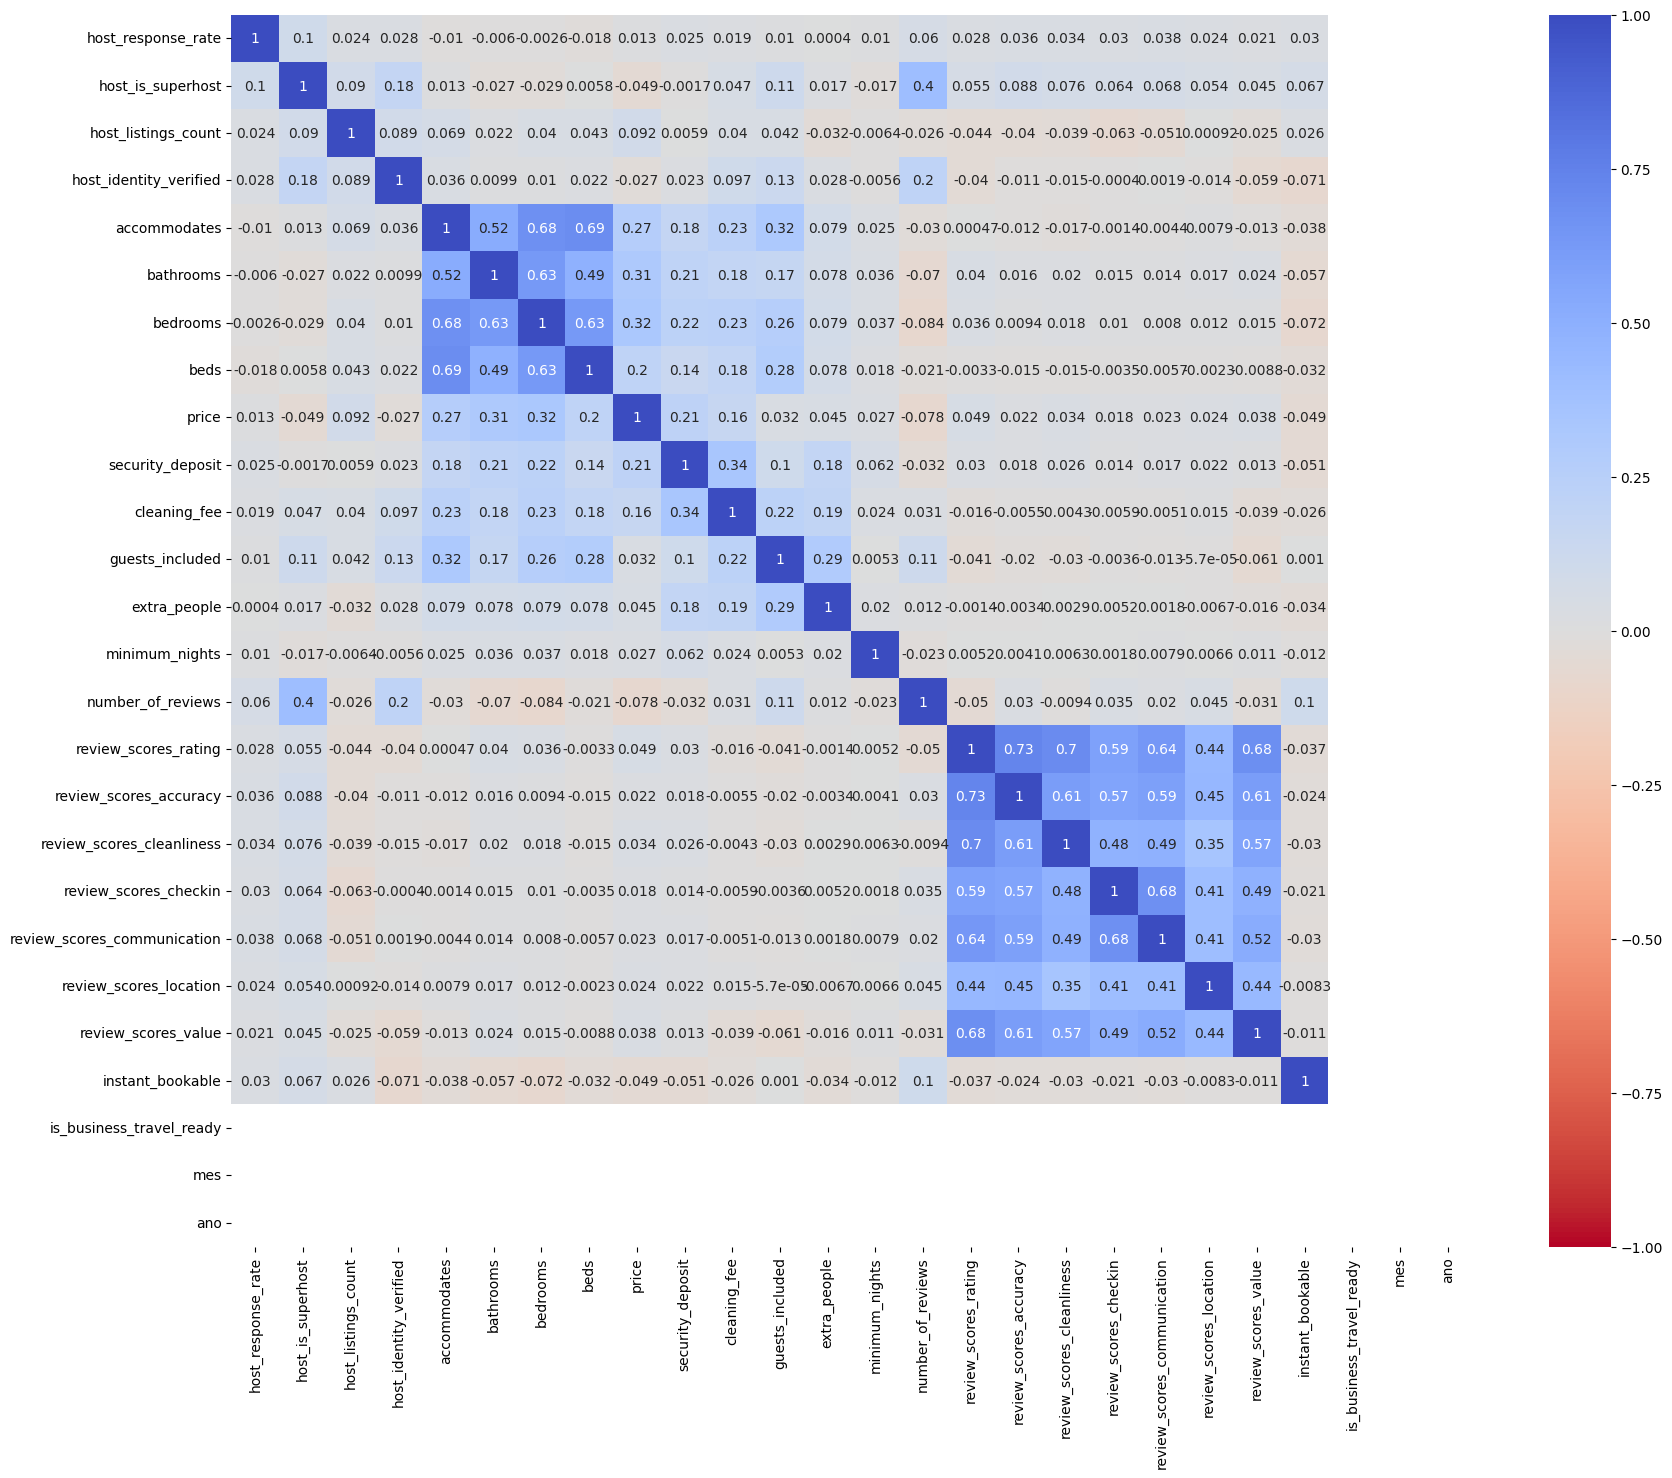

In [28]:
analise_numericas_df = analise_df.select_dtypes(include = "number")

plt.figure(figsize = (20,16))
sns.heatmap(analise_numericas_df.corr(), annot = True, cmap = "coolwarm_r" , vmin = -1)

plt.show()

Podemos observar que algumas das colunas de review possuem forte correlação em geral, com excessão da coluna de avaliação do local do imóvel. Por isso vamos manter em nosso modelo somente as colunas review_scores_rating e review_scores_location.

In [29]:
analise_df = analise_df.drop(columns = ["review_scores_accuracy","review_scores_cleanliness","review_scores_checkin","review_scores_communication","review_scores_value"])
display(analise_df.iloc[0])

host_response_rate                                                      100.0
host_is_superhost                                                           0
host_listings_count                                                       1.0
host_identity_verified                                                      1
neighbourhood_cleansed                                               Botafogo
property_type                                                       Apartment
room_type                                                     Entire home/apt
accommodates                                                                4
bathrooms                                                                 1.0
bedrooms                                                                  0.0
beds                                                                      2.0
amenities                   {TV,Internet,"Air conditioning",Kitchen,Doorma...
price                                                           

Definição de funções para análise de outliers

Vamos separar as variáveis em categóricas, numéricas e alvo

In [30]:
df_categoricas = analise_df.select_dtypes(exclude = 'number')
df_numericas = analise_df.select_dtypes(include = 'number')
df_alvo = analise_df["price"]

In [69]:
def limites(coluna):
    q1 = coluna.quantile(0.25)
    q3 = coluna.quantile(0.75)
    amplitude = q3 - q1
    sup = q3 + 1.5*amplitude
    inf = q1 - 1.5*amplitude
    return inf , sup

def boxplot(coluna):
    fig , ax = plt.subplots(nrows = 1 , ncols = 2, figsize = (10 , 8))
    fig.set_size_inches(15 , 5)
    ax0 = sns.boxplot(y = coluna , ax = ax[0])
    ax1 = sns.boxplot(y = coluna , ax = ax[1])
    ax1.set_ylim(limites(coluna))

def distribuicao(coluna , hist):
    fig, ax = plt.subplots(figsize = (15,5))
    if hist == True:
        ax1 = sns.histplot(coluna , fill = True, ax = ax)
        ax1.tick_params(axis = "x" , rotation = 90)
    else:
        ax1 = sns.kdeplot(coluna , fill = True, ax = ax)
        ax1.tick_params(axis = "x" , rotation = 90)
    #ax1 = sns.histplot(coluna , ax = ax)
    
def box_price(coluna):
    fig , ax = plt.subplots(nrows =1 , ncols =2, figsize= (10 , 6))
    ax0 = sns.boxplot(x = coluna , y = 'price' , data = analise_df, ax = ax[0])
    ax0.tick_params(axis = 'x' , rotation = 90)
    ax1 = sns.boxplot(x = coluna , y = 'price' , data = analise_df , ax = ax[1])
    ax1.tick_params(axis = 'x' , rotation = 90)
    ax1.set_ylim(limites(df_alvo))

In [82]:
# análise variáveis cateóricas:

df_categoricas['amenities'].value_counts()


amenities
{}                                                                                                                                                                                                                                                                   9850
{TV,"Cable TV",Internet,Wifi,"Air conditioning",Kitchen,Doorman,Elevator,"Buzzer/wireless intercom",Washer}                                                                                                                                                           450
{"Family/kid friendly"}                                                                                                                                                                                                                                               408
{TV,"Cable TV",Internet,Wifi,"Air conditioning",Kitchen,Doorman,Elevator,"Buzzer/wireless intercom","Family/kid friendly",Washer}                                                               